In [35]:
from sallypy.repos import TimeSeriesRepo, CrossSectionalDataRepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch



ts_repo = TimeSeriesRepo()
returns = ts_repo.get_monthly_returns(["BFS_CNZ_STUDY_INCOME", "BFS_CNZ_STUDY_GROWTH", "BFS_CNZ_STUDY_CASH"])
returns.columns = ["Bonds", "Stocks", "Cash"]
returns.dropna(inplace=True)

cs_repo = CrossSectionalDataRepo()

exp_returns = cs_repo.get_all("2025-08-01", "Long-term Net Expected Return", None,  ["CNZ_STUDY_INCOME", "CNZ_STUDY_GROWTH", "CNZ_STUDY_CASH"])

In [36]:
import numpy as np
import pandas as pd


def cholesky_bootstrap_returns(n: int, s: int, cov: pd.DataFrame, exp_ret: pd.DataFrame) -> np.ndarray:
    """
    Simulate returns using the Cholesky decomposition of the covariance matrix.
    Parameters
    ----------
    n : int
        Number of simulations.
    s : int
        Length of the simulation.
    cov : pandas.DataFrame
        Covariance matrix.
    exp_ret : pandas.DataFrame
        Expected returns.

    Returns
    -------
    np.array
        n x s x num_assets tensor

    """
    rng = np.random.default_rng()
    y = rng.multivariate_normal(exp_ret.values.flatten(), cov.values, size=(n, s))
    return y


def simulate_wealth(
    simulated_returns: np.ndarray,
    weights: np.ndarray,
    initial_wealth: float,
    cashflows: np.ndarray,
    transactions: np.ndarray,
    inflation: float = 0.03,
    time_steps: np.ndarray = None,
) -> np.ndarray:
    """
    Simulate wealth using the simulated returns and weights.
    Parameters
    ----------
    simulated_returns : np.array
        n x s x n_assets tensor of simulated returns.
    weights : np.array
        s x num_assets matrix of weights.
    initial_wealth : float
        Initial wealth.
    cashflows : np.array
        s x 1 vector of cashflows.
    transactions : np.array
        s x 1 vector of transactions.
    inflation : float, optional
        Inflation rate. Default is 0.03.
    time_steps : np.array, optional
        s+1 x 1 vector of time steps. If None, will be set to np.arange(0, s + 1).
    Returns
    -------
    np.array
        n x s+1 matrix of wealth.
    """

    n = simulated_returns.shape[0]  # number of simulations
    s = simulated_returns.shape[1]  # number of time steps
    k = simulated_returns.shape[2]  # number of assets
    
    wealth = np.zeros((n, s + 1))  # wealth array
    wealth[:, 0] = initial_wealth  # set initial wealth
    if time_steps is None:
        time_steps = np.arange(0, s + 1)  # time steps
    time_delta = np.diff(time_steps)  # time delta

    assert len(cashflows) == s, "Cashflows must be the same length as the number of time steps"
    assert len(transactions) == s, "Transactions must be the same length as the number of time steps"
    assert len(time_steps) == s + 1, "Time steps must be the same length as the number of time steps + 1"
    assert weights.shape[0] == s, "Weights first dimension must be the same length as the number of time steps"
    assert weights.shape[1] == k, "Weights second dimension must be the same length as the number of assets"
    assert len(time_delta) == s, "Time delta must be the same length as the number of time steps - 1"
    assert np.all(time_delta > 0), "Time steps must be in ascending order"
    assert np.all(np.isfinite(simulated_returns)), "Simulated returns must be finite"
    assert np.all(np.isfinite(weights)), "Weights must be finite"
    assert np.all(np.isfinite(cashflows)), "Cashflows must be finite"
    assert np.all(np.isfinite(transactions)), "Transactions must be finite"
    assert np.all(np.isfinite(initial_wealth)), "Initial wealth must be finite"
    assert np.all(np.isfinite(time_steps)), "Time steps must be finite"

    # inflation_factor = 1
    # for i in range(s):
    #     inflation_factor *= (1 + inflation) ** time_delta[i]
    #     wealth[:, i + 1] = (
    #         wealth[:, i] * (weights[i] * (1 + simulated_returns[:, i, :]) ** time_delta[i]).sum(axis=1) + (cashflows[i]*time_delta[i] + transactions[i]) * inflation_factor 
    #     )
    #     wealth[wealth[:, i + 1] < 0, i + 1] = 0  # set negative wealth to 0

    # weights: (s, k) => broadcast to (n, s, k)
    weights_broadcast = weights[np.newaxis, :, :]  # (1, s, k)

    # time_delta: (s,) => broadcast to (n, s, 1)
    time_delta_broadcast = time_delta[np.newaxis, :, np.newaxis]  # (1, s, 1)

    growth_factor = ((1 + simulated_returns) ** time_delta_broadcast)
    portfolio_returns = np.sum(weights_broadcast * growth_factor, axis=2)  # shape: (n, s)

    wealth = np.zeros((n, s + 1))
    wealth[:, 0] = initial_wealth

    for i in range(s):
        wealth[:, i + 1] = (
            wealth[:, i] * portfolio_returns[:, i] +
            (cashflows[i] * time_delta[i] + transactions[i])
        )

    return wealth


def convert_to_real_wealth(
    wealth: np.ndarray, time_steps: np.ndarray, inflation: float = 0.03, 
) -> np.array:
    """
    Convert wealth to real wealth using the inflation rate.
    Parameters
    ----------
    wealth : np.array
        n x s+1 matrix of wealth.
    inflation : float, optional
        Inflation rate. Default is 0.03.
    time_steps : np.array, optional
        s+1 x 1 vector of time steps. If None, will be set to np.arange(0, s + 1).
    Returns
    -------
    np.array
        n x s+1 matrix of real wealth.
    """
    assert np.all(np.isfinite(wealth)), "Wealth must be finite"
    assert np.all(np.isfinite(time_steps)), "Time steps must be finite"

    inflation_factor = (1 + inflation) ** time_steps
    return wealth / inflation_factor.reshape(1, -1)




In [37]:
# def simulate_wealth_pytorch(
#     simulated_returns: torch.Tensor,
#     weights: torch.Tensor,
#     initial_wealth: float,
#     cashflows: torch.Tensor,
#     transactions: torch.Tensor,
#     inflation: float = 0.03,
#     time_steps: torch.Tensor = None,
# ) -> torch.Tensor:
#     """
#     Simulate wealth using the simulated returns and weights.
#     Parameters
#     ----------
#     simulated_returns : torch.Tensor
#         n x s x n_assets tensor of simulated returns.
#     weights : torch.Tensor
#         s x num_assets matrix of weights.
#     initial_wealth : float
#         Initial wealth.
#     cashflows : torch.Tensor
#         s x 1 vector of cashflows.
#     transactions : torch.Tensor
#         s x 1 vector of transactions.
#     inflation : float, optional
#         Inflation rate. Default is 0.03.
#     time_steps : torch.Tensor, optional
#         s+1 x 1 vector of time steps. If None, will be set to np.arange(0, s + 1).
#     Returns
#     -------
#     torch.Tensor
#         n x s+1 matrix of wealth.
#     """

#     n = simulated_returns.shape[0]  # number of simulations
#     s = simulated_returns.shape[1]  # number of time steps
#     k = simulated_returns.shape[2]  # number of assets

#     wealth = torch.zeros((n, s + 1))  # wealth array
#     wealth[:, 0] = initial_wealth  # set initial wealth
#     if time_steps is None:
#         time_steps = torch.arange(0, s + 1)  # time steps

#     # assert len(cashflows) == s, "Cashflows must be the same length as the number of time steps"
#     # assert len(transactions) == s, "Transactions must be the same length as the number of time steps"
#     # assert len(time_steps) == s + 1, "Time steps must be the same length as the number of time steps + 1"
#     # assert weights.shape[0] == s, "Weights first dimension must be the same length as the number of time steps"
#     # assert weights.shape[1] == k, "Weights second dimension must be the same length as the number of assets"
#     # assert len(time_steps) == s + 1, "Time steps must be the same length as the number of time steps + 1"
#     # assert np.all(np.isfinite(simulated_returns)), "Simulated returns must be finite"
#     # assert np.all(np.isfinite(weights)), "Weights must be finite"
#     # assert np.all(np.isfinite(cashflows)), "Cashflows must be finite"
#     # assert np.all(np.isfinite(transactions)), "Transactions must be finite"
#     # assert np.all(np.isfinite(initial_wealth)), "Initial wealth must be finite"
#     # assert np.all(np.isfinite(time_steps)), "Time steps must be finite"
#     # assert np.all(time_steps[1:] > time_steps[:-1]), "Time steps must be in ascending order"
#     # assert inflation > 0, "Inflation must be positive"
#     # assert inflation < 1, "Inflation must be less than 1"
#     # assert inflation < 1, "Inflation must be less than 1"

#     weights_broadcast = weights.unsqueeze(0)  # (1, s, k)
#     time_delta = torch.diff(time_steps)  # time delta (s,)
#     time_delta_broadcast = time_delta.unsqueeze(0).unsqueeze(-1)  # (1, s, 1)
#     growth_factor = ((1 + simulated_returns) ** time_delta_broadcast)  # (n, s, k)
#     portfolio_returns = torch.sum(weights_broadcast * growth_factor, dim=2)  # shape: (n, s)


# )

In [38]:
exp_returns.T.values

array([[0.02424656, 0.08069473, 0.01407   ]])

In [39]:
yearly_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)
yearly_cov = yearly_returns.cov()
exp_yearly_returns = yearly_returns.mean()
exp_yearly_returns = exp_returns.T

spending_weights = {
    spend: None for spend in np.linspace(0.01, 0.1, 19)
}
spending_risks = {
    spend: None for spend in np.linspace(0.01, 0.1, 19)
}
torch.cuda.empty_cache()
for spend_percent in spending_weights.keys():

    torch.cuda.empty_cache()
    
    print(f"Spending percent: {spend_percent}")

    # Parameters
    N = int(1e6)
    S = 30 # years
    initial_wealth = 1000000
    inflation = 0.03 #annual inflation
    RETIRMENT_YEAR = 0 # years
    cashflows = np.zeros(S) # cashflows
    cashflows[RETIRMENT_YEAR:] = -initial_wealth * spend_percent # cashflows after retirement
    cashflows[:RETIRMENT_YEAR] = 10000 # cashflows before retirement (e.g. savings)
    cashflows = torch.tensor(cashflows, dtype=torch.float32, requires_grad=True)
    cashflows = cashflows.to(device="cuda")

    weights = torch.full((S, len(yearly_returns.columns)-1), 0.0, requires_grad=True)
    weights.data.clamp_(0.0, 1.0)
    # weights = weights.to(device="cuda")

    # simulated_returns = cholesky_bootstrap_returns(
    #     N, S, yearly_cov, yearly_returns.mean()
    # )

    t_returns_cpu = torch.tensor(cholesky_bootstrap_returns(N, S, yearly_cov, exp_yearly_returns))
    val_returns_cpu = torch.tensor(cholesky_bootstrap_returns(N, S, yearly_cov, exp_yearly_returns))


    optimizer = torch.optim.Adam([weights], lr=0.01)


    def total_destitution_cost(cost_, wealth, sharpness=5e-6, only_retirement=False):
        if only_retirement:
            return cost_ + -torch.sigmoid(wealth[RETIRMENT_YEAR+1:, :] * sharpness).sum()/(N*(S-1))
        else:
            return cost_ + -torch.sigmoid(wealth[1:, :] * sharpness).sum()/(N*(S-1))

    def final_destitution_cost(cost_, wealth, sharpness=5e-6):
        cost_ += -torch.sigmoid(wealth[-1, :] * sharpness).sum()/(N*(S-1))
        return cost_

    def weight_smoothing(cost_, weights, smoothing=1/10, alpha=0.5):
        s_m1 = weights[0, :]
        for z in range(1, weights.shape[0]):
            s_m1 = weights[z, :]
            x_z = weights[z-1, :]
            s_z = s_m1 - alpha * (x_z - s_m1)
            cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing
        return cost_

    def weight_smoothing_about_retirement(cost_, weights, smoothing=1/10, alpha=0.4):
        s_m1 = weights[0, :]
        for z in range(1, RETIRMENT_YEAR):
            s_m1 = weights[z, :]
            x_z = weights[z-1, :]
            s_z = s_m1 - alpha * (x_z - s_m1)
            cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing

        # Post-retirement smoothing
        s_m1 = weights[RETIRMENT_YEAR, :]
        for z in range(1, S-RETIRMENT_YEAR):
            s_m1 = weights[RETIRMENT_YEAR+z, :]
            x_z = weights[RETIRMENT_YEAR+z-1, :]
            s_z = s_m1 - alpha * (x_z - s_m1)
            cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing

        return cost_

    import time

    inflation_factor = (1 + inflation) ** torch.arange(S).float()
    inflation_factor = inflation_factor.to(device="cuda")
    inflation_cashflows = (torch.ones(N, S).to(device="cuda") * (cashflows * inflation_factor)).T
    inflation_cashflows = inflation_cashflows.to(device="cuda")
    min_cost = 100000000
    without_improvement_count = 0
    best_weights = weights.clone().detach()  # Store the best weights found during optimisation
    for optimisation_step in range(100000):

        optimizer.zero_grad()

        wealth = torch.zeros((S + 1, N))
        wealth[0, :] = initial_wealth  # set initial wealth
        wealth = wealth.to(device="cuda")
        s = time.time()

        # copy returns and send to device
        t_returns = t_returns_cpu.to(device="cuda")

        for i in range(S):
            stock_weight = weights[i, 0]
            bond_weight = (1 - weights[i, 0]) * weights[i, 1]
            cash_weight = 1 - stock_weight - bond_weight


            wealth[i + 1, :] = (
                (wealth[i, :] + inflation_cashflows[i])
                * (bond_weight * (1 + t_returns[:, i, 0]) + stock_weight * (1 + t_returns[:, i, 1]) + cash_weight * (1 + t_returns[:, i, 2]))
                )
        wealth = torch.where(wealth > 0, wealth, torch.zeros_like(wealth).to(device="cuda"))
        # print("wealth simulation time", time.time() - s)
        del t_returns

        cost_ = torch.zeros(1,).to(device="cuda")
        cost_ = total_destitution_cost(cost_, wealth, only_retirement=True)
        # cost_ = final_destitution_cost(cost_, wealth.T)
        # cost_ = weight_smoothing_about_retirement(cost_, weights)
        cost_ = weight_smoothing(cost_, weights, alpha=0.1, smoothing=1/1000)
        # cost_ = cost_.to(device="cuda")
        s = time.time()
        cost_.backward(retain_graph=True)
        # print("backward time", time.time() - s)
        optimizer.step()
        with torch.no_grad():
            weights.clamp_(0.0, 1.0)

        # calculate validation cost
        # val_wealth = torch.zeros((S + 1, N))
        # val_wealth[0, :] = initial_wealth
        # val_wealth = val_wealth.to(device="cuda")
        # # copy returns and send to device
        # val_returns = val_returns_cpu.to(device="cuda")
        # for i in range(S):
        #     stock_weight = weights[i, 0]
        #     bond_weight = 1 - weights[i, 0] 
        #     # send to device
        #     bond_weight = bond_weight.to(device="cuda")
        #     stock_weight = stock_weight.to(device="cuda")

        #     val_wealth[i + 1, :] = (
        #         (val_wealth[i, :] + inflation_cashflows[i])
        #         * (bond_weight * (1 + val_returns[:, i, 0]) + stock_weight * (1 + val_returns[:, i, 1]))
        #         )
        # val_wealth = torch.where(val_wealth > 0, val_wealth, torch.zeros_like(val_wealth).to(device="cuda"))
        # val_cost_ = torch.zeros(1,).to(device="cuda")
        # val_cost_ = total_destitution_cost(val_cost_, val_wealth, only_retirement=True)
        # del val_returns
        # val_cost_ = final_destitution_cost(val_cost_, val_wealth.T)
        # val_cost_ = weight_smoothing_about_retirement(val_cost_, weights)
        # val_cost_ = weight_smoothing(val_cost_, weights, alpha=0.1, smoothing=1/1000)
        # val_cost_ = val_cost_.to(device="cuda")

        # print(f"Optimisation step {optimisation_step}: {cost_.item()} (validation: {val_cost_.item()})")
        print(f"Optimisation step {optimisation_step}: {cost_.item()}")
        # print(f"Weights: {weights}")
        print("destitution risk", torch.sum(wealth[-1, :] <= 0).item()/N)
        # new_min_cost = min(min_cost, torch.sum(wealth[:, :] <= 0).item()/N)
        # new_min_cost = min(min_cost, val_cost_.item())
        new_min_cost = min(min_cost, cost_.item())
        if new_min_cost < min_cost:
            min_cost = new_min_cost
            without_improvement_count = 0
            best_weights = weights.clone().detach()
        else:
            without_improvement_count += 1
        if without_improvement_count > 100:
            print("No improvement for 20 steps, stopping optimisation")
            break
        print(f"stock weight: {weights.mean(dim=0)[0].item()}")
        # print(f"bond weight: {1 - weights.mean(dim=0)[0].item()}")




    weights_numpy = weights.cpu().detach().numpy()

    spending_weights[spend_percent] = best_weights.detach().numpy()
    spending_risks[spend_percent] = torch.sum(wealth[-1, :] <= 0).item() / N

    # clear GPU memory
    torch.cuda.empty_cache()


Spending percent: 0.01
Optimisation step 0: -1.0263761281967163
destitution risk 0.0
stock weight: 0.009999885223805904
Optimisation step 1: -1.0269441604614258
destitution risk 0.0
stock weight: 0.019962793216109276
Optimisation step 2: -1.0274608135223389
destitution risk 0.0
stock weight: 0.029863612726330757
Optimisation step 3: -1.0279291868209839
destitution risk 0.0
stock weight: 0.03967754915356636
Optimisation step 4: -1.0283527374267578
destitution risk 0.0
stock weight: 0.04938063770532608
Optimisation step 5: -1.0287351608276367
destitution risk 0.0
stock weight: 0.05895022302865982
Optimisation step 6: -1.0290799140930176
destitution risk 0.0
stock weight: 0.06836534291505814
Optimisation step 7: -1.0293902158737183
destitution risk 0.0
stock weight: 0.07760702818632126
Optimisation step 8: -1.0296694040298462
destitution risk 0.0
stock weight: 0.08665855973958969
Optimisation step 9: -1.0299205780029297
destitution risk 0.0
stock weight: 0.09550554305315018
Optimisation s

In [42]:
weights

array([[1.        , 0.7781678 ],
       [1.        , 0.78053343],
       [1.        , 0.78530467],
       [1.        , 0.7917963 ],
       [1.        , 0.7987488 ],
       [1.        , 0.80518323],
       [1.        , 0.8105614 ],
       [1.        , 0.8140896 ],
       [1.        , 0.81668264],
       [1.        , 0.8189792 ],
       [1.        , 0.82099885],
       [1.        , 0.8227799 ],
       [1.        , 0.8243359 ],
       [1.        , 0.8256869 ],
       [1.        , 0.8269095 ],
       [1.        , 0.82803446],
       [1.        , 0.8290706 ],
       [1.        , 0.8300172 ],
       [1.        , 0.83087283],
       [1.        , 0.83164454],
       [1.        , 0.83234185],
       [1.        , 0.8329694 ],
       [1.        , 0.83352745],
       [1.        , 0.83401537],
       [1.        , 0.8344316 ],
       [1.        , 0.8347728 ],
       [1.        , 0.83504945],
       [1.        , 0.83525974],
       [1.        , 0.8354081 ],
       [1.        , 0.8354747 ]], dtype=flo

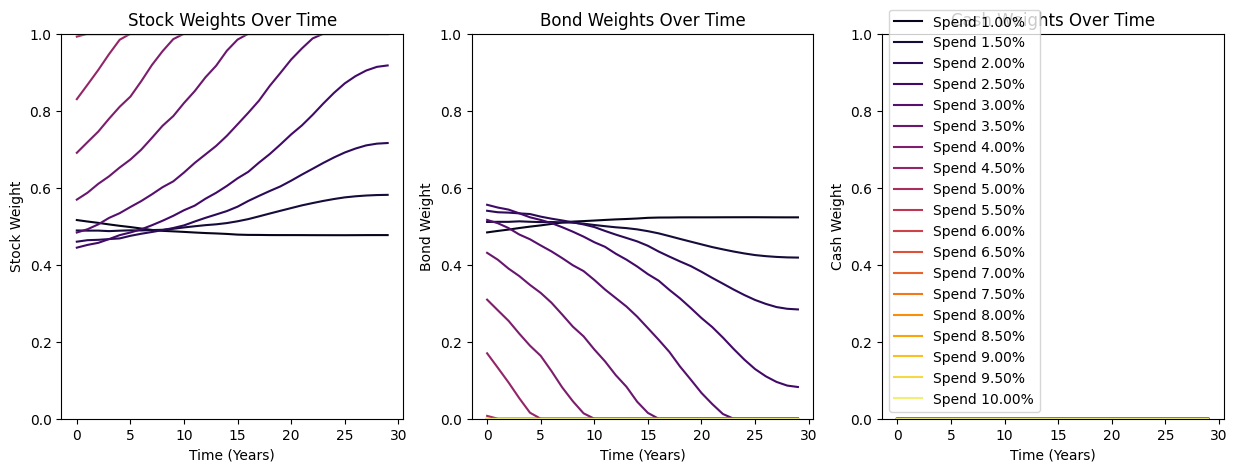

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
colour_ramp = sns.color_palette("inferno", n_colors=len(spending_weights))
for spend, weights in spending_weights.items():
    ax.plot(weights[:, 0], label=f"Spend {spend:.2%}", c = colour_ramp[int(spend * 200) - 2])
ax.set_title("Stock Weights Over Time")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Stock Weight")
ax.set_ylim(0, 1)

ax = axes[1]
for spend, weights in spending_weights.items():
    ax.plot((1 - weights[:, 0]) * weights[:, 1], label=f"Spend {spend:.2%}", c = colour_ramp[int(spend * 200) - 2])
ax.set_title("Bond Weights Over Time")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Bond Weight")
ax.set_ylim(0, 1)

ax = axes[2]
for spend, weights in spending_weights.items():
    ax.plot(1 - weights[:, 0] - (1 - weights[:, 0]) * weights[:, 1], label=f"Spend {spend:.2%}", c = colour_ramp[int(spend * 200) - 2])
ax.set_title("Cash Weights Over Time")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Cash Weight")
ax.set_ylim(0, 1)
ax.legend()



In [59]:
exp_yearly_returns

,Ticker,CNZ_STUDY_INCOME,CNZ_STUDY_GROWTH,CNZ_STUDY_CASH
,Name,Consilium Income Allocation for Lifetime Study,Consilium Equity Allocation for Lifetime Study,Consilium Cash Allocation for Lifetime Study
Metric,Currency,,,
Long-term Net Expected Return,NaN,0.024247,0.080695,0.01407


In [52]:
weight_grid = np.array(list(spending_weights.values()))

In [53]:
weight_grid


array([[[0.5160469 , 1.        ],
        [0.51221496, 1.        ],
        [0.508739  , 1.        ],
        ...,
        [0.47691524, 1.        ],
        [0.47697765, 1.        ],
        [0.476961  , 1.        ]],

       [[0.4889623 , 1.        ],
        [0.48856074, 1.        ],
        [0.4886208 , 1.        ],
        ...,
        [0.5797384 , 1.        ],
        [0.58095664, 1.        ],
        [0.581471  , 1.        ]],

       [[0.45983994, 1.        ],
        [0.46373734, 1.        ],
        [0.46468562, 1.        ],
        ...,
        [0.7099727 , 1.        ],
        [0.71447027, 1.        ],
        [0.7161157 , 1.        ]],

       ...,

       [[1.        , 0.78835076],
        [1.        , 0.79085314],
        [1.        , 0.79550046],
        ...,
        [1.        , 0.8502463 ],
        [1.        , 0.85035574],
        [1.        , 0.8504024 ]],

       [[1.        , 0.7828309 ],
        [1.        , 0.78527975],
        [1.        , 0.78988934],
        .

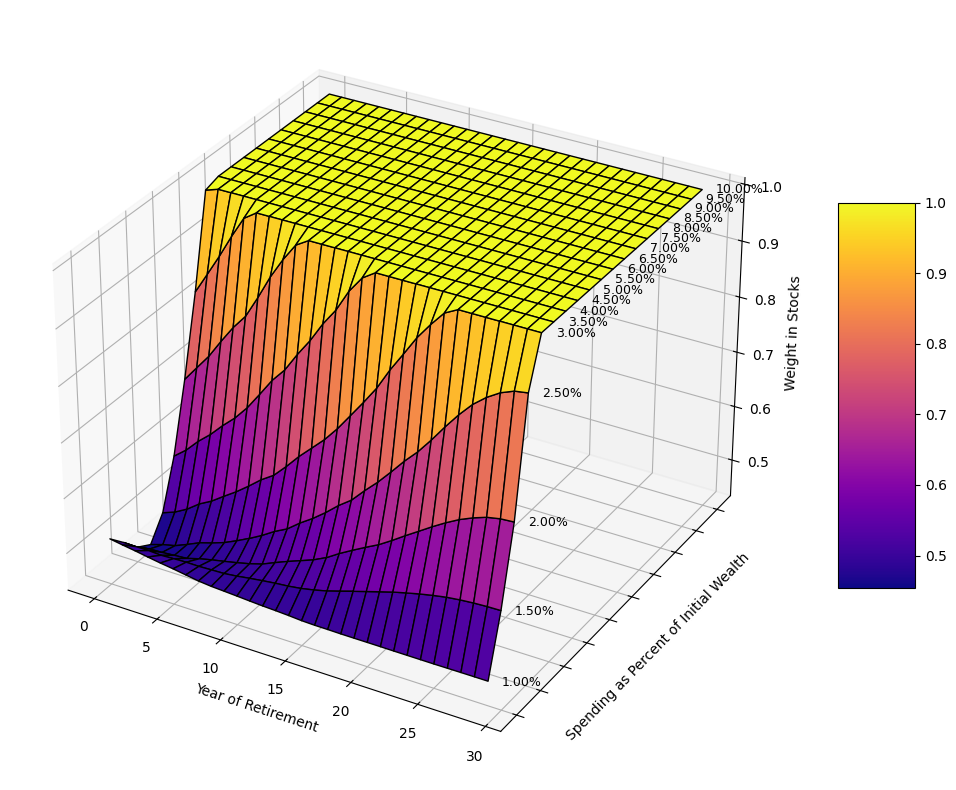

In [57]:

# plot 3d plot of spending weights
weight_grid = np.array(list(spending_weights.values()))[:, :, 0]  # Extract stock weights
weight_grid = weight_grid.reshape(len(spending_weights), -1)
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
Y = np.arange(weight_grid.shape[0])
X = np.arange(weight_grid.shape[1])
X, Y = np.meshgrid(X, Y)
Z = weight_grid  # Transpose to match the shape for plotting
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='k')

# place labels at the end of the traces for different spending percentages
final_weights = weight_grid[:, -1]
for i, spend in enumerate(spending_weights.keys()):
    ax.text(Y[-1, i]+12, X[-1, i], final_weights[i], f"{spend:.2%}", color='black', fontsize=9)

# ax.text(30, 1, 1, "Spending Percent", color='black', fontsize=12)

ax.set_xlabel('Year of Retirement')
ax.set_ylabel('Spending as Percent of Initial Wealth')
ax.set_zlabel('Weight in Stocks')
#set y ticks to spending percent
ax.set_yticks(range(len(spending_risks))[::2], labels=[f"" for spend in spending_weights.keys()][::2])
# hide y ticks
# ax.set_yticks([])
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

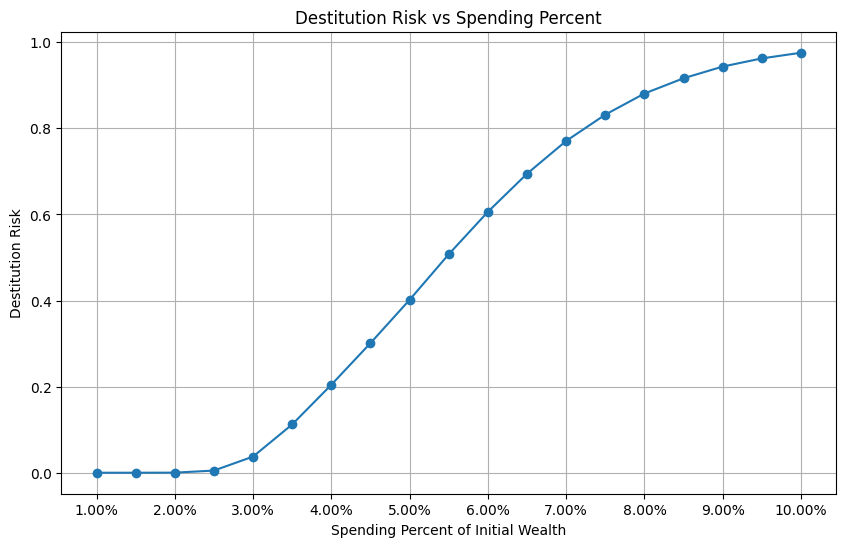

In [30]:
# plot destitution risk
plt.figure(figsize=(10, 6))
plt.plot(list(spending_risks.keys()), list(spending_risks.values()), marker='o')
plt.xlabel("Spending Percent of Initial Wealth")
plt.ylabel("Destitution Risk")
plt.title("Destitution Risk vs Spending Percent")
plt.xticks(list(spending_risks.keys())[::2], labels=[f"{spend:.2%}" for spend in spending_risks.keys()][::2])
plt.grid()

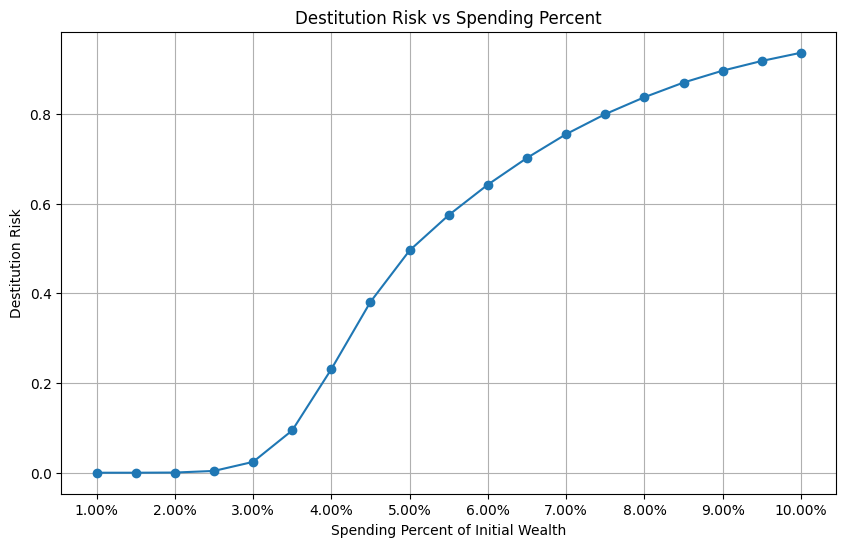

In [8]:
# plot destitution risk
plt.figure(figsize=(10, 6))
plt.plot(list(spending_risks.keys()), list(spending_risks.values()), marker='o')
plt.xlabel("Spending Percent of Initial Wealth")
plt.ylabel("Destitution Risk")
plt.title("Destitution Risk vs Spending Percent")
plt.xticks(list(spending_risks.keys())[::2], labels=[f"{spend:.2%}" for spend in spending_risks.keys()][::2])
plt.grid()

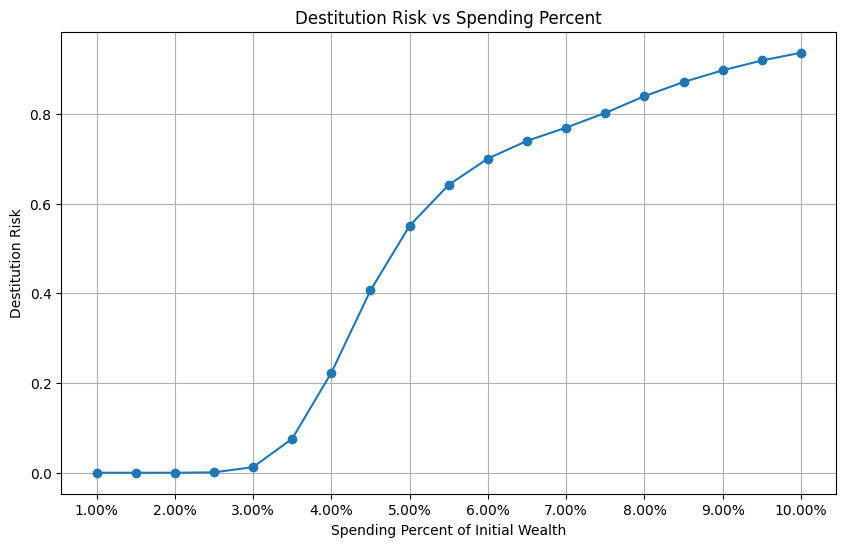

In [25]:
# plot destitution risk
plt.figure(figsize=(10, 6))
plt.plot(list(spending_risks.keys()), list(spending_risks.values()), marker='o')
plt.xlabel("Spending Percent of Initial Wealth")
plt.ylabel("Destitution Risk")
plt.title("Destitution Risk vs Spending Percent")
plt.xticks(list(spending_risks.keys())[::2], labels=[f"{spend:.2%}" for spend in spending_risks.keys()][::2])
plt.grid()

In [ ]:
def total_destitution_cost(wealth, weights, smoothing=1/10, alpha=0.5, sharpness=1e-6):
    cost_ = -torch.sigmoid(wealth[1:, :] * sharpness).sum()/(N*(S-1))
    s_m1 = weights[0, :]
    for z in range(1, weights.shape[0]):
        s_m1 = weights[z, :]
        x_z = weights[z-1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z)**2)/weights.shape[1] * smoothing
        
    return cost_


In [ ]:
cost_ = total_destitution_cost(wealth, weights)
cost_.backward()

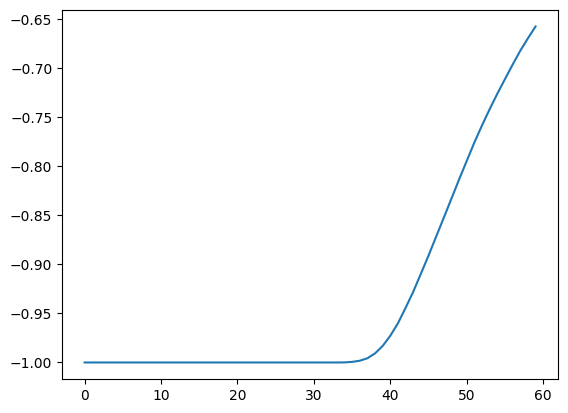

In [75]:
plt.plot((-torch.sigmoid(wealth[1:, :]).sum(dim=1)/N).detach().numpy())

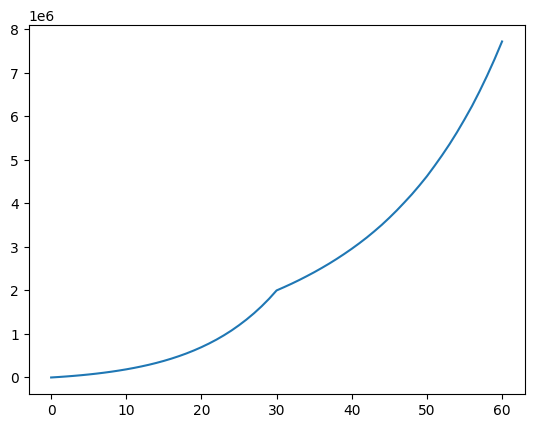

In [63]:
plt.plot(wealth.mean(dim=1).detach().numpy())

In [68]:
wealth

tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 9.5000e+03,  1.1448e+04,  8.8819e+03,  ...,  1.1939e+04,
          1.0964e+04,  1.0949e+04],
        [ 2.2234e+04,  2.6233e+04,  1.9315e+04,  ...,  1.9748e+04,
          2.2613e+04,  2.2447e+04],
        ...,
        [ 8.8182e+06,  9.3877e+06,  1.5908e+07,  ..., -1.8136e+06,
          8.8654e+07,  4.0329e+05],
        [ 1.0515e+07,  9.3984e+06,  1.9771e+07,  ..., -2.6192e+06,
          1.0964e+08,  1.7434e+05],
        [ 1.1364e+07,  8.7523e+06,  2.2667e+07,  ..., -3.2970e+06,
          1.2215e+08, -5.9914e+04]], grad_fn=<CopySlices>)

In [ ]:
import numpy as np


def interpolate_weights(wealth

In [ ]:
import torch

def bilinear_interp_torch(t_vals, W_vals, time_grid, wealth_grid, control_matrix):
    """
    Differentiable bilinear interpolation in PyTorch.

    Parameters:
        t_vals: (N,) Tensor of time values
        W_vals: (N,) Tensor of wealth values
        time_grid: (T,) Tensor of time grid
        wealth_grid: (M,) Tensor of wealth grid
        control_matrix: (T, M) Tensor of control values (requires_grad=True)

    Returns:
        (N,) Tensor of interpolated control values
    """
    T = time_grid.shape[0]
    M = wealth_grid.shape[0]

    # Find indices of surrounding grid points
    t_idx = torch.clamp(torch.searchsorted(time_grid, t_vals, right=True) - 1, 0, T - 2)
    W_idx = torch.clamp(torch.searchsorted(wealth_grid, W_vals, right=True) - 1, 0, M - 2)

    # Grid values
    t0 = time_grid[t_idx]
    t1 = time_grid[t_idx + 1]
    W0 = wealth_grid[W_idx]
    W1 = wealth_grid[W_idx + 1]

    # Weights
    alpha = (t_vals - t0) / (t1 - t0 + 1e-8)
    beta = (W_vals - W0) / (W1 - W0 + 1e-8)

    # Gather 2D control values
    def gather_2d(mat, i, j):
        return mat[i, j]

    p00 = control_matrix[t_idx,     W_idx]
    p10 = control_matrix[t_idx + 1, W_idx]
    p01 = control_matrix[t_idx,     W_idx + 1]
    p11 = control_matrix[t_idx + 1, W_idx + 1]

    # Bilinear interpolation
    interpolated = (
        (1 - alpha) * (1 - beta) * p00 +
        alpha * (1 - beta) * p10 +
        (1 - alpha) * beta * p01 +
        alpha * beta * p11
    )

    return interpolated
  

In [2]:
# Sample grid
time_grid = torch.tensor([0.0, 1.0, 2.0])
wealth_grid = torch.tensor([0.0, 1.0, 2.0, 3.0])

# Make control matrix trainable
control_matrix = torch.tensor([
    [0.1, 0.2, 0.25, 0.3],
    [0.15, 0.25, 0.3, 0.35],
    [0.2, 0.3, 0.35, 0.4]
], requires_grad=True)

# Monte Carlo (t, W) points
t_vals = torch.tensor([0.5, 1.2, 0.9])
W_vals = torch.tensor([1.5, 2.4, 0.7])

# Interpolate and compute a dummy loss
interpolated = bilinear_interp_torch(t_vals, W_vals, time_grid, wealth_grid, control_matrix)
loss = interpolated.sum()

# Backpropagate
loss.backward()

print("Interpolated:", interpolated)
print("Gradient w.r.t. control_matrix:\n", control_matrix.grad)

Interpolated: tensor([0.2500, 0.3300, 0.2150], grad_fn=<AddBackward0>)
Gradient w.r.t. control_matrix:
 tensor([[0.0300, 0.3200, 0.2500, 0.0000],
        [0.2700, 0.8800, 0.7300, 0.3200],
        [0.0000, 0.0000, 0.1200, 0.0800]])


In [15]:
from sallypy.repos import KiwiWrapAilRepo, FirmsRepo


kiwi_repo = KiwiWrapAilRepo()

ail = kiwi_repo.get_all(active_as_of="2025-09-01", return_df=True)
firms = FirmsRepo().get_all(return_df=True)
import pandas as pd



In [21]:
issuers = firms.copy()
issuers.columns = [f"Issuer {col}" for col in issuers.columns]

managers = firms.copy()
managers.columns = [f"Manager {col}" for col in managers.columns]

ail_firms = pd.merge(left=ail, right=managers, left_on="Fund manager", right_on="Name", how="left")
ail_firms = pd.merge(left=ail_firms, right=issuers, left_on="Fund issuer", right_on="Name", how="left")

In [23]:
ail_firms.to_csv("ail_firms.csv", index=False)

In [41]:

from sallypy.repos import TimeSeriesRepo
ts_repo = TimeSeriesRepo()
returns = ts_repo.get_monthly_returns(["BFS_OCR.25", "BMK0131"])
returns.columns = ["MortgageInterest", "HousePrice",]
returns['MortgageInterest'] = returns['MortgageInterest']
returns.dropna(inplace=True)




In [48]:
annual_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)
annual_returns["MortgageInterest"] = annual_returns["MortgageInterest"] + 0.03
annual_returns.to_csv("mortgage_house_returns.csv")

In [47]:
annual_returns.corr()

,MortgageInterest,HousePrice
MortgageInterest,1.000000,-0.091315
HousePrice,-0.091315,1.000000


In [40]:
(1+0.0024319269262773613) **12 - 1

0.029576646498397974